In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from IPython.display import display
from statsmodels.formula.api import ols
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
#load processed data
client_data = pd.read_csv('../data/processed/client_analysis_data.csv')

# --- dataset preview ---
print("\n🔎 Dataset Preview:")
display(client_data.head())

print("\n📊 Dataset Shape:")
print(client_data.shape)

print("\nℹ️ Dataset Info:")
print(client_data.info())

print("\n📈 Summary Statistics:")
print(client_data.describe(include='all').transpose())


🔎 Dataset Preview:


,client_id,age,income_bracket,risk_tolerance,investment_experience,join_date,country,tenure_days,account_balance,last_updated,...,total_trade_value,avg_trade_value,std_trade_value,total_quantity,avg_quantity,total_transaction_value,transaction_count,deposit_ratio,avg_daily_trades,value_per_trade
0,C10000,54,Medium,Very High,Beginner,2020-02-16,Canada,2040,11119,2025-09-16 18:10:22.208536,...,2070146.74,20496.50,14622.27,10030,99.31,52091.0,10,0.80,0.049510,20496.502376
1,C10001,61,Medium,Low,Beginner,2025-11-15,Canada,-59,27182,2025-09-16 18:10:22.214717,...,2466664.64,25170.05,18070.90,10828,110.49,27182.0,1,1.00,98.000000,25170.047347
2,C10002,27,Medium,Very High,Intermediate,2024-08-17,Germany,396,46465,2025-09-16 18:10:22.216712,...,2056016.16,22593.58,16463.27,9686,106.44,46815.0,2,0.50,0.229798,22593.584176
3,C10003,23,Low,Very High,Intermediate,2022-02-03,Germany,1322,25315,2025-09-16 18:10:22.217713,...,1998764.47,21725.70,17154.08,9172,99.70,34596.0,3,0.67,0.069592,21725.700761
4,C10004,57,Medium,High,Advanced,2025-11-07,Australia,-51,21668,2025-09-16 18:10:22.218707,...,1841425.29,19383.42,15530.80,8619,90.73,21668.0,1,1.00,95.000000,19383.424105



📊 Dataset Shape:
(1000, 21)

ℹ️ Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   client_id                1000 non-null   object 
 1   age                      1000 non-null   int64  
 2   income_bracket           1000 non-null   object 
 3   risk_tolerance           1000 non-null   object 
 4   investment_experience    1000 non-null   object 
 5   join_date                1000 non-null   object 
 6   country                  1000 non-null   object 
 7   tenure_days              1000 non-null   int64  
 8   account_balance          1000 non-null   int64  
 9   last_updated             1000 non-null   object 
 10  trade_count              1000 non-null   int64  
 11  total_trade_value        1000 non-null   float64
 12  avg_trade_value          1000 non-null   float64
 13  std_trade_value          1000 no

In [3]:
#1. statistical tests
#compare trading activity across risk tolerance groups
print("\nANOVA: Trade Count by Risk Tolerance")
model = ols('trade_count ~ C(risk_tolerance)', data=client_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

print("\nT-test: Account Balance by Income Bracket")
high_income = client_data[client_data['income_bracket'] == 'High']['account_balance']
low_income = client_data[client_data['income_bracket'] == 'Low']['account_balance']
t_stat, p_value = stats.ttest_ind(high_income, low_income, equal_var=False)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")


ANOVA: Trade Count by Risk Tolerance
                          sum_sq     df         F    PR(>F)
C(risk_tolerance)      18.482671    3.0  0.060879  0.980331
Residual           100793.517329  996.0       NaN       NaN

T-test: Account Balance by Income Bracket
T-statistic: 0.9240, P-value: 0.3558


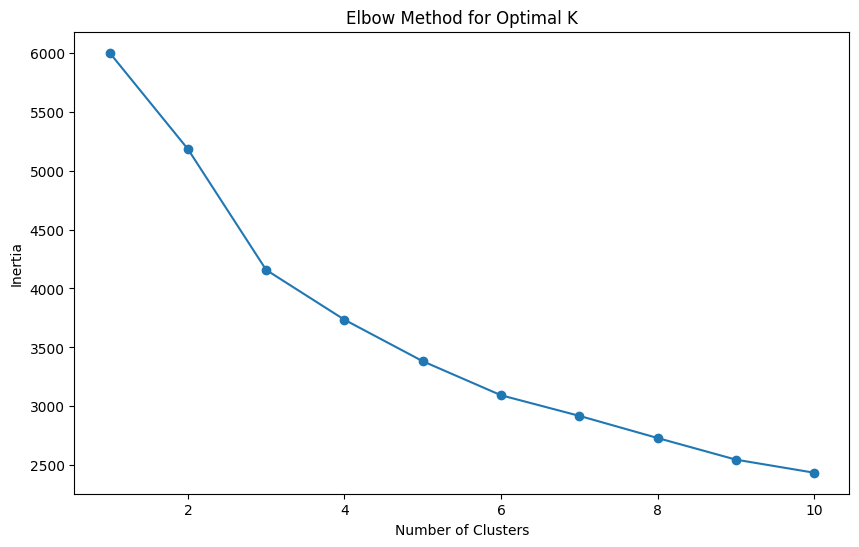


Cluster Summary:
         Avg Age  Avg Balance  Avg Trade Count  Avg Trade Value  Avg Tenure  \
cluster                                                                       
0          50.25     17286.28           103.05         22069.66      948.34   
1          54.70     32952.33            95.98         20000.39     1038.14   
2          28.08     31107.82           100.56         21185.15     1145.52   
3          46.57     27996.02            98.76         20990.92      -52.43   

        Common Risk Tolerance  Client Count  
cluster                                      
0                        High           321  
1                        High           279  
2                   Very High           354  
3                        High            46  


In [4]:
#2. client segmentation using k-means clustering
#select features for clustering
cluster_features = client_data[['age', 'account_balance', 'trade_count', 
                               'avg_trade_value', 'tenure_days', 'avg_daily_trades']].dropna()

#standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

#determine optimal number of clusters using elbow method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig('../reports/elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

#apply k-means with optimal clusters
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
client_data['cluster'] = kmeans.fit_predict(scaled_features)

#analyze cluster characteristics
cluster_summary = client_data.groupby('cluster').agg({
    'age': 'mean',
    'account_balance': 'mean',
    'trade_count': 'mean',
    'avg_trade_value': 'mean',
    'tenure_days': 'mean',
    'risk_tolerance': lambda x: x.mode()[0],
    'client_id': 'count'
}).round(2)

cluster_summary.columns = ['Avg Age', 'Avg Balance', 'Avg Trade Count', 
                          'Avg Trade Value', 'Avg Tenure', 'Common Risk Tolerance', 'Client Count']
print("\nCluster Summary:")
print(cluster_summary)


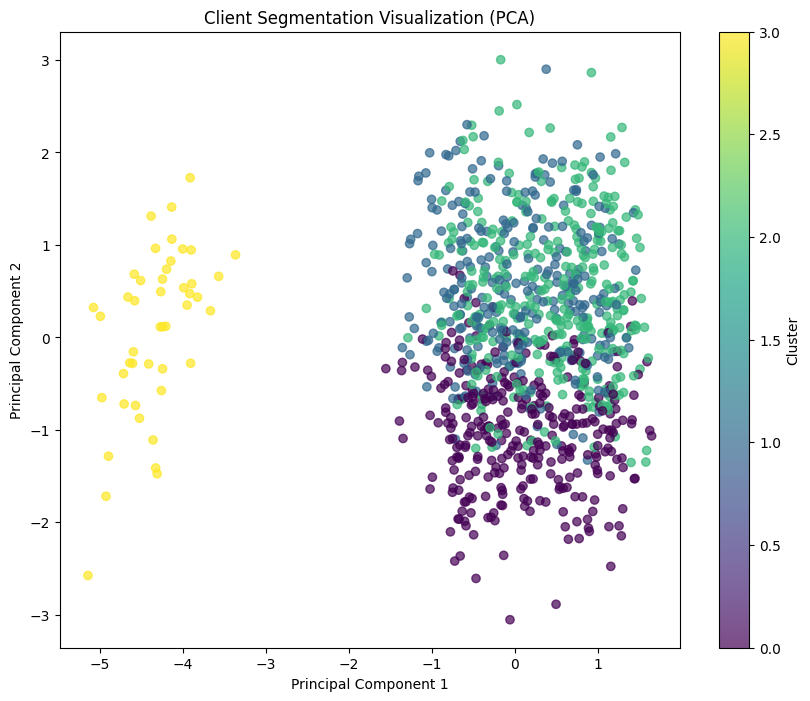

In [5]:
#3. PCA for dimensionality reduction and visualization
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_features[:, 0], pca_features[:, 1], 
                     c=client_data['cluster'], cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Client Segmentation Visualization (PCA)')
plt.savefig('../reports/client_segmentation_pca.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
#4. Risk profiling
#calculate risk score based on trading behavior
client_data['volatility_score'] = client_data['std_trade_value'] / client_data['avg_trade_value'].replace(0, 1)
client_data['activity_score'] = (client_data['trade_count'] - client_data['trade_count'].mean()) / client_data['trade_count'].std()
client_data['size_score'] = (client_data['avg_trade_value'] - client_data['avg_trade_value'].mean()) / client_data['avg_trade_value'].std()

#combine scores for overall risk profile
client_data['behavioral_risk_score'] = (
    client_data['volatility_score'].fillna(0) + 
    client_data['activity_score'].fillna(0) + 
    client_data['size_score'].fillna(0)
)

#normalize risk score to 1-10 scale
min_score = client_data['behavioral_risk_score'].min()
max_score = client_data['behavioral_risk_score'].max()
client_data['behavioral_risk_score'] = 1 + 9 * (client_data['behavioral_risk_score'] - min_score) / (max_score - min_score)

print("\nRisk Score Summary:")
print(client_data['behavioral_risk_score'].describe())

#compare with self-reported risk tolerance
risk_comparison = client_data.groupby('risk_tolerance')['behavioral_risk_score'].mean()
print("\nBehavioral Risk Score by Self-Reported Risk Tolerance:")
print(risk_comparison)

#save results
client_data.to_csv('../data/processed/client_data_with_segments.csv', index=False)

print("\nStatistical analysis and client segmentation completed!")


Risk Score Summary:
count    1000.000000
mean        5.113617
std         1.311624
min         1.000000
25%         4.254928
50%         5.142160
75%         6.005042
max        10.000000
Name: behavioral_risk_score, dtype: float64

Behavioral Risk Score by Self-Reported Risk Tolerance:
risk_tolerance
High         5.138894
Low          5.061716
Medium       5.165791
Very High    5.084414
Name: behavioral_risk_score, dtype: float64

Statistical analysis and client segmentation completed!
